# EDA — NCBI Disease Corpus
Format: PubTator  
KB: MeSH  
Entity types: SpecificDisease, DiseaseClass, Modifier, CompositeMention

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('../data/raw/ncbi_disease')
TRAIN_FILE = DATA_DIR / 'NCBItrainset_corpus.txt'
DEV_FILE   = DATA_DIR / 'NCBIdevelopset_corpus.txt'
TEST_FILE  = DATA_DIR / 'NCBItestset_corpus.txt'

## 1. Parser

In [2]:
def parse_pubtator(filepath):
    """
    Parse a PubTator-format file.
    Returns:
        docs   : list of dicts  {pmid, title, abstract}
        mentions: list of dicts {pmid, start, end, text, entity_type, mesh_ids}
    """
    docs, mentions = [], []
    current = {}

    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip('\n')

            if '|t|' in line:
                pmid, _, title = line.split('|', 2)
                current = {'pmid': pmid, 'title': title, 'abstract': ''}

            elif '|a|' in line:
                _, _, abstract = line.split('|', 2)
                current['abstract'] = abstract
                docs.append(current)

            elif line.strip() == '':
                current = {}

            else:
                parts = line.split('\t')
                if len(parts) >= 6:
                    pmid, start, end, text, etype, mesh_raw = parts[:6]
                    mesh_ids = mesh_raw.strip().split('|')  # handles CompositeMention
                    mentions.append({
                        'pmid'       : pmid,
                        'start'      : int(start),
                        'end'        : int(end),
                        'text'       : text,
                        'entity_type': etype,
                        'mesh_ids'   : mesh_ids,
                        'is_composite': len(mesh_ids) > 1
                    })

    return docs, mentions


train_docs, train_mentions = parse_pubtator(TRAIN_FILE)
dev_docs,   dev_mentions   = parse_pubtator(DEV_FILE)
test_docs,  test_mentions  = parse_pubtator(TEST_FILE)

train_df = pd.DataFrame(train_mentions)
dev_df   = pd.DataFrame(dev_mentions)
test_df  = pd.DataFrame(test_mentions)

print(f'Train  — docs: {len(train_docs):>4}  mentions: {len(train_df):>5}')
print(f'Dev    — docs: {len(dev_docs):>4}  mentions: {len(dev_df):>5}')
print(f'Test   — docs: {len(test_docs):>4}  mentions: {len(test_df):>5}')

Train  — docs:  593  mentions:  5145
Dev    — docs:  100  mentions:   787
Test   — docs:  100  mentions:   960


## 2. Quick look at the data

In [3]:
train_df.head(10)

,pmid,start,end,text,entity_type,mesh_ids,is_composite
0,10192393,15,26,skin tumour,DiseaseClass,[D012878],False
1,10192393,443,449,cancer,DiseaseClass,[D009369],False
2,10192393,483,496,colon cancers,DiseaseClass,[D003110],False
3,10192393,539,565,adenomatous polyposis coli,SpecificDisease,[D011125],False
4,10192393,567,570,APC,SpecificDisease,[D011125],False
5,10192393,670,698,colon and some other cancers,CompositeMention,"[D003110, D009369]",True
6,10192393,855,867,skin tumours,DiseaseClass,[D012878],False
7,10192393,879,893,pilomatricomas,SpecificDisease,[D018296],False
8,10192393,1021,1035,pilomatricomas,SpecificDisease,[D018296],False
9,10192393,1210,1221,skin tumour,DiseaseClass,[D012878],False


In [4]:
train_df.info()
train_df['entity_type'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 5145 entries, 0 to 5144
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   pmid          5145 non-null   str   
 1   start         5145 non-null   int64 
 2   end           5145 non-null   int64 
 3   text          5145 non-null   str   
 4   entity_type   5145 non-null   str   
 5   mesh_ids      5145 non-null   object
 6   is_composite  5145 non-null   bool  
dtypes: bool(1), int64(2), object(1), str(3)
memory usage: 246.3+ KB


entity_type
SpecificDisease     2972
Modifier            1289
DiseaseClass         769
CompositeMention     115
Name: count, dtype: int64

## 3. Entity type distribution

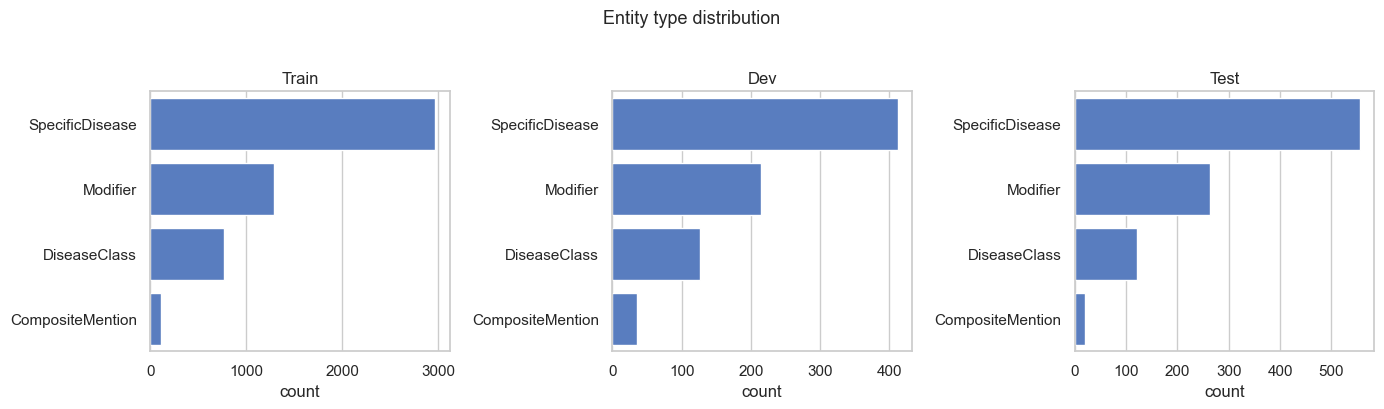

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (df, split) in zip(axes, [(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]):
    counts = df['entity_type'].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, orient='h')
    ax.set_title(split)
    ax.set_xlabel('count')
    ax.set_ylabel('')

plt.suptitle('Entity type distribution', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Mention length distribution (in characters)

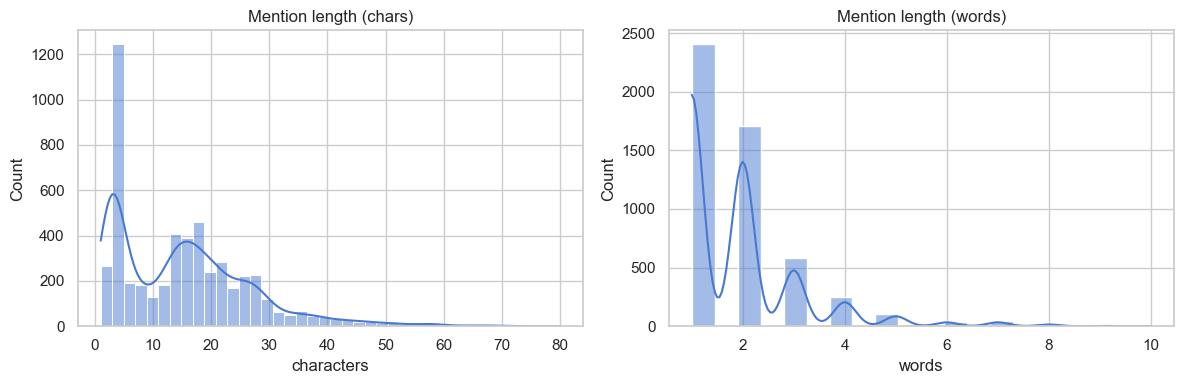

       mention_len  mention_words
count      5145.00        5145.00
mean         15.19           1.90
std          11.79           1.21
min           1.00           1.00
25%           3.00           1.00
50%          14.00           2.00
75%          22.00           2.00
max          80.00          10.00


In [6]:
train_df['mention_len'] = train_df['text'].str.len()
train_df['mention_words'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df['mention_len'], bins=40, ax=axes[0], kde=True)
axes[0].set_title('Mention length (chars)')
axes[0].set_xlabel('characters')

sns.histplot(train_df['mention_words'], bins=20, ax=axes[1], kde=True)
axes[1].set_title('Mention length (words)')
axes[1].set_xlabel('words')

plt.tight_layout()
plt.show()

print(train_df[['mention_len', 'mention_words']].describe().round(2))

## 5. Mentions per document

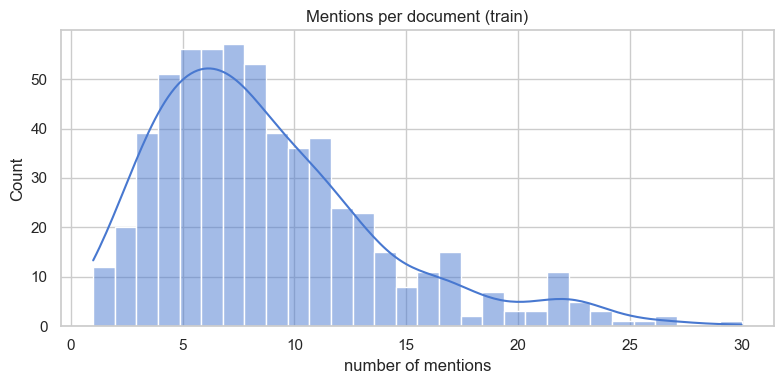

count    592.00
mean       8.69
std        5.17
min        1.00
25%        5.00
50%        8.00
75%       11.00
max       30.00
dtype: float64


In [7]:
mentions_per_doc = train_df.groupby('pmid').size()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(mentions_per_doc, bins=30, ax=ax, kde=True)
ax.set_title('Mentions per document (train)')
ax.set_xlabel('number of mentions')
plt.tight_layout()
plt.show()

print(mentions_per_doc.describe().round(2))

## 6. Composite mentions

In [8]:
n_composite = train_df['is_composite'].sum()
print(f'Composite mentions: {n_composite} ({100*n_composite/len(train_df):.1f}%)')
print()
print('Examples:')
train_df[train_df['is_composite']][['text', 'mesh_ids']].head(10)

Composite mentions: 93 (1.8%)

Examples:


,text,mesh_ids
5,colon and some other cancers,"[D003110, D009369]"
33,breast or ovarian cancer,"[D001943, D010051]"
77,disorder of lymphocyte homeostasis and immunol...,"[D008232, D007154]"
218,breast and ovarian cancer,"[D001943, D010051]"
223,breast or ovarian cancer,"[D001943, D010051]"
225,breast or ovarian cancer,"[D001943, D010051]"
559,breast and squamous cell neoplasms,"[D001943, D018307]"
657,cleft lip/palate,"[D002971, D002972]"
658,CL/P,"[D002971, D002972]"
665,CL/P,"[D002971, D002972]"


## 7. KB coverage — how many mentions map to a valid MeSH ID?

In [9]:
# NIL mentions have no valid MeSH ID (sometimes marked as -1 or empty)
def is_nil(mesh_ids):
    return any(m.strip() in ['-1', '', 'None', 'OMIM'] for m in mesh_ids)

train_df['is_nil'] = train_df['mesh_ids'].apply(is_nil)

nil_count = train_df['is_nil'].sum()
print(f'NIL mentions : {nil_count} ({100*nil_count/len(train_df):.1f}%)')
print(f'Mapped       : {len(train_df)-nil_count} ({100*(1-nil_count/len(train_df)):.1f}%)')

# NIL breakdown by entity type
train_df.groupby('entity_type')['is_nil'].mean().mul(100).round(1).rename('nil_%')

NIL mentions : 0 (0.0%)
Mapped       : 5145 (100.0%)


entity_type
CompositeMention    0.0
DiseaseClass        0.0
Modifier            0.0
SpecificDisease     0.0
Name: nil_%, dtype: float64

## 8. Most frequent mentions and MeSH IDs

In [10]:
print('=== Top 15 most frequent mention texts ===')
print(train_df['text'].str.lower().value_counts().head(15).to_string())
print()

all_mesh = [m for ids in train_df['mesh_ids'] for m in ids if m not in ['-1','','None']]
print('=== Top 15 most frequent MeSH IDs ===')
print(pd.Series(Counter(all_mesh)).sort_values(ascending=False).head(15).to_string())

=== Top 15 most frequent mention texts ===
text
dm                             120
dmd                            109
apc                             91
ald                             86
pws                             75
myotonic dystrophy              71
was                             63
g6pd deficiency                 57
hd                              55
aniridia                        53
pku                             52
breast cancer                   44
duchenne muscular dystrophy     44
vhl                             40
fap                             39

=== Top 15 most frequent MeSH IDs ===
D000326    209
D009223    191
D011125    189
D020388    170
D009369    164
D011218    112
D005955    100
D030342     99
D010661     97
D014923     94
D001943     88
D006816     81
D010051     77
D013661     77
D001260     69


## 9. Unique MeSH IDs (KB size)

In [11]:
unique_mesh_train = set(m for ids in train_df['mesh_ids'] for m in ids if m not in ['-1','','None'])
unique_mesh_test  = set(m for ids in test_df['mesh_ids']  for m in ids if m not in ['-1','','None'])

print(f'Unique MeSH IDs in train : {len(unique_mesh_train)}')
print(f'Unique MeSH IDs in test  : {len(unique_mesh_test)}')
print(f'Test IDs not seen in train (zero-shot): {len(unique_mesh_test - unique_mesh_train)}')

Unique MeSH IDs in train : 656
Unique MeSH IDs in test  : 200
Test IDs not seen in train (zero-shot): 61


## 10. Surface form variation — how many texts map to the same MeSH ID?

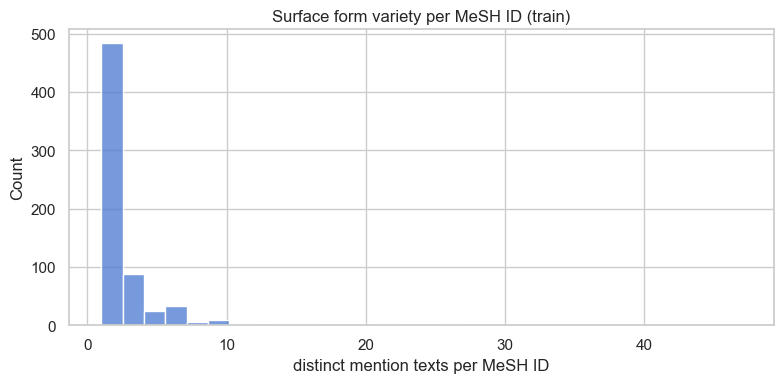

Mean surface forms per MeSH ID: 2.54
Max surface forms for one ID  : 47

Most ambiguous MeSH IDs:
  D030342: 47 forms → ['allelic disorders', 'trinucleotide repeat disorders', 'hereditary multisystemic disease', 'autosomal recessive genetic disorder', 'autosomal recessive syndrome']
  D009369: 26 forms → ['bilateral and multifocal tumours', 'cancer', 'sporadic tumours', 'mcf-7 tumours', 'neoplastic']
  D005955: 26 forms → ['g6pd deficient', 'deficient in glucose-6-phosphate dehydrogenase', 'glucose-6-phosphate dehydrogenase (g6pd; ec 1. 1. 1. 49) deficiency', 'glucose-6-phosphate dehydrogenase (g6pd; e. c. 1. 1. 1. 49) deficiency', 'x-linked glucose-6-phosphate dehydrogenase deficiency']
  D061325: 25 forms → ['breast-ovarian cancer syndrome', 'breast-ovarian syndrome', 'familial breast and ovarian cancers', 'breast and/or ovarian cancer', 'hereditary breast or ovarian cancer']
  D010051: 22 forms → ['ovarian cancers', 'breast and ovarian carcinomas', 'ovarian or breast cancer', 'ovari

In [12]:
# For each MeSH ID, how many distinct surface forms exist?
mesh_to_surfaces = {}
for _, row in train_df[~train_df['is_nil']].iterrows():
    for mid in row['mesh_ids']:
        mesh_to_surfaces.setdefault(mid, set()).add(row['text'].lower())

surface_counts = pd.Series({k: len(v) for k, v in mesh_to_surfaces.items()})

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(surface_counts, bins=30, ax=ax)
ax.set_title('Surface form variety per MeSH ID (train)')
ax.set_xlabel('distinct mention texts per MeSH ID')
plt.tight_layout()
plt.show()

print(f'Mean surface forms per MeSH ID: {surface_counts.mean():.2f}')
print(f'Max surface forms for one ID  : {surface_counts.max()}')
print()
print('Most ambiguous MeSH IDs:')
top_ids = surface_counts.sort_values(ascending=False).head(5)
for mid, cnt in top_ids.items():
    print(f'  {mid}: {cnt} forms → {list(mesh_to_surfaces[mid])[:5]}')

## 11. Summary stats

In [13]:
summary = {
    'split'            : ['train', 'dev', 'test'],
    'documents'        : [len(train_docs), len(dev_docs), len(test_docs)],
    'mentions'         : [len(train_df), len(dev_df), len(test_df)],
    'unique_mesh_ids'  : [
        len(set(m for ids in train_df['mesh_ids'] for m in ids if m not in ['-1','','None'])),
        len(set(m for ids in dev_df['mesh_ids']   for m in ids if m not in ['-1','','None'])),
        len(set(m for ids in test_df['mesh_ids']  for m in ids if m not in ['-1','','None'])),
    ],
    'composite_%'      : [
        round(100*train_df['is_composite'].mean(), 1),
        round(100*dev_df['is_composite'].mean(), 1),
        round(100*test_df['is_composite'].mean(), 1),
    ],
}

pd.DataFrame(summary).set_index('split')

,documents,mentions,unique_mesh_ids,composite_%
split,,,,
train,593,5145,656,1.8
dev,100,787,172,2.5
test,100,960,200,1.6
